In [31]:
# PARAMÉTEREK

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


months = 6
pattern = ['W', 'L', 'W', 'L', 'W', 'L']  # 6 hónapos minta

start_users = 10
new_users_per_month = 3
monthly_price = 8000
base_churn = 0.30  # 20%
extra_churn_per_loss_streak = 0.05  # +5% churn per extra loss
churn_reduction_per_win = 0.05 # -5% churn per win

In [32]:
# SZIMULÁCIÓ

# 1. Kohort követés bevezetése
# users_by_cohort: kulcs = belépés hónapja (1, 2, 3...), érték = {létszám: int, pattern: ['W', 'L', ...]}
# Kezdő felhasználók (start_users) az 1. hónap kohortjába kerülnek.
users_by_cohort = {
    1: {'active': start_users, 'lifetime_pattern': []}
}

# 2. DataFrame és Churn/Bevétel listák
df = pd.DataFrame({
    'Month': np.arange(1, months+1),
    'Pattern': pattern
})

df['Price'] = monthly_price
discounts = []
churn_rates = []
revenues = []
active_end = []

# 3. Churn követés a Churn rate számításához
loss_streak = 0
win_streak = 0
current_active_users = start_users

for i in range(months):
    month = i + 1
    outcome = df.loc[i, 'Pattern']
    
    # Új felhasználók beléptetése (minden hónapban, kivéve az elsőt, mivel ott a start_users van)
    new_users = new_users_per_month if month > 1 else 0
    if new_users > 0:
        users_by_cohort[month] = {'active': new_users, 'lifetime_pattern': []}
        current_active_users += new_users
        
    df.loc[i, 'Active_start'] = current_active_users
    df.loc[i, 'New_users'] = new_users

    
    # ----------------------------------------------------
    # A) CHURN RATE számítás (A teljes populációra vonatkozik)
    # ----------------------------------------------------
    if outcome == 'L':
        loss_streak += 1
        win_streak = 0
    else:
        loss_streak = 0
        win_streak += 1
        
    churn_rate = base_churn
    if loss_streak > 1:
        churn_rate += (loss_streak - 1) * extra_churn_per_loss_streak
    elif win_streak > 0:
        # A pozitív hónapok csökkentik a churn-t (maximum a teljes csökkentés a base_churn-ig)
        churn_rate -= win_streak * churn_reduction_per_win
        
    # Korlátok
    churn_rate = np.clip(churn_rate, 0.05, 0.95)
    churn_rates.append(churn_rate)
    
    
    # ----------------------------------------------------
    # B) KEDVEZMÉNY ÉS BEVÉTEL SZÁMÍTÁS (Kohort-specifikus)
    # ----------------------------------------------------
    total_revenue = 0
    
    # Frissítjük a kohortokat a Churn és a Pattern alapján
    keys_to_delete = []
    
    for cohort_id, data in users_by_cohort.items():
        cohort_users = data['active']
        
        # 1. Churn számítás
        churned = int(cohort_users * churn_rate)
        remaining_users = cohort_users - churned
        
        # 2. Kedvezmény meghatározása
        # CSAK a 2. hónapban belépő (cohort_id=2) felhasználók kapnak kedvezményt
        discount = 1.0 # Alapértelmezett: teljes ár
        
        if cohort_id == 2:
            # 2. kohortnak a 2. hónap az első, a 3. hónap a második, a 4. hónap a harmadik
            # month (i+1) a szimuláció aktuális hónapja
            
            if month == 3:
                # 3. hónap díja kedvezményes, ha a 2. hónap (első hónap) veszteséges volt
                if df.loc[1, 'Pattern'] == 'L': # df.loc[1] = 2. hónap
                    discount = 0.5 # 50% kedvezmény
                    
            elif month == 4:
                # 4. hónap díja ingyenes, ha a 2. ÉS 3. hónap veszteséges volt
                if df.loc[1, 'Pattern'] == 'L' and df.loc[2, 'Pattern'] == 'L':
                    discount = 0.0 # 100% kedvezmény (ingyen)

        # 3. Bevétel hozzáadása a teljeshez
        total_revenue += remaining_users * monthly_price * discount
        
        # 4. Kohort adatainak frissítése
        data['active'] = remaining_users
        data['lifetime_pattern'].append(outcome)
        
        if remaining_users <= 0:
             keys_to_delete.append(cohort_id)
        
    # Töröljük az inaktív kohortokat
    for k in keys_to_delete:
        del users_by_cohort[k]


    # ----------------------------------------------------
    # C) Összegzés és a következő hónap előkészítése
    # ----------------------------------------------------
    revenues.append(total_revenue)
    
    current_active_users = sum(data['active'] for data in users_by_cohort.values())
    active_end.append(current_active_users)
    
    # Megjegyzés: A 'Discount' oszlop ezentúl csak tájékoztató jellegű, 
    # mert a bevétel több kedvezményből tevődik össze.
    discounts.append(1.0) # Vagy: round(total_revenue / (current_active_users * monthly_price), 2)
    

df['Discount'] = [round(r / (df.loc[i, 'Active_start'] * monthly_price) if df.loc[i, 'Active_start'] > 0 else 1.0, 2) for i, r in enumerate(revenues)]
df['Churn_rate'] = churn_rates
df['Revenue'] = revenues
df['Active_end'] = active_end
df['Cumulative_revenue'] = df['Revenue'].cumsum()

,Month,Pattern,Active_start,New_users,Discount,Churn_rate,Revenue,Active_end,Cumulative_revenue
0,1,W,10.0,0.0,0.80,0.25,64000.0,8,64000.0
1,2,L,11.0,3.0,0.82,0.30,72000.0,9,136000.0
2,3,W,12.0,3.0,0.79,0.25,76000.0,11,212000.0
3,4,L,14.0,3.0,0.93,0.30,104000.0,13,316000.0
4,5,W,16.0,3.0,0.94,0.25,120000.0,15,436000.0
5,6,L,18.0,3.0,1.00,0.30,144000.0,18,580000.0


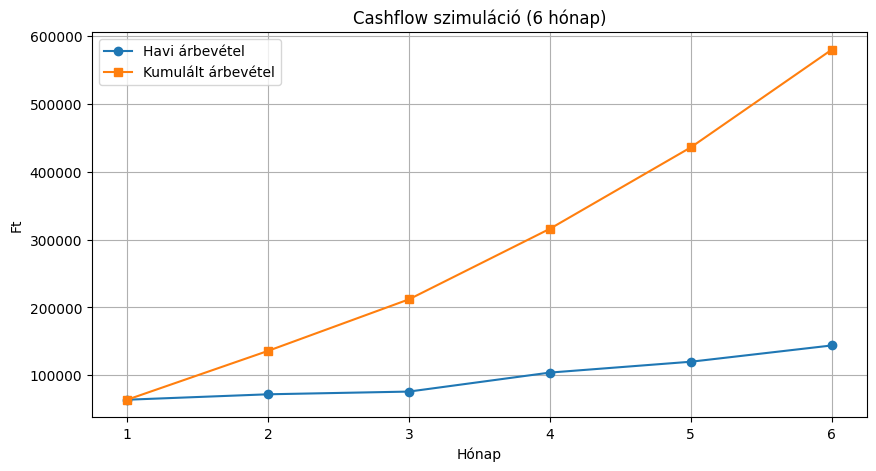

Összes árbevétel 6 hónap alatt: 96,667 Ft
Átlagos churn: 27.5%


In [33]:
# EREDMÉNYEK MEGJELENÍTÉSE

display(df[['Month','Pattern','Active_start','New_users','Discount','Churn_rate','Revenue','Active_end','Cumulative_revenue']]) 

plt.figure(figsize=(10,5))
plt.plot(df['Month'], df['Revenue'], marker='o', label='Havi árbevétel')
plt.plot(df['Month'], df['Cumulative_revenue'], marker='s', label='Kumulált árbevétel')
plt.title("Cashflow szimuláció (6 hónap)")
plt.xlabel("Hónap")
plt.ylabel("Ft")
plt.legend()
plt.grid(True)
plt.show()

print(f"Összes árbevétel 6 hónap alatt: {df['Revenue'].mean():,.0f} Ft")
print(f"Átlagos churn: {df['Churn_rate'].mean()*100:.1f}%")